## How to Train YOLOv8 Object Detection on a Custom Dataset

In [ ]:
!nvidia-smi

Tue Feb 25 13:37:55 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install ultralytics

## Install YOLOv8

In [ ]:
from ultralytics import YOLO
import os
from IPython.display import display, Image
from IPython import display
display.clear_output()
!yolo mode=checks

Traceback (most recent call last):
  File "/usr/local/bin/yolo", line 8, in <module>
    sys.exit(entrypoint())
             ^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/ultralytics/cfg/__init__.py", line 919, in entrypoint
    raise ValueError(f"Invalid 'mode={mode}'. Valid modes are {MODES}.\n{CLI_HELP_MSG}")
ValueError: Invalid 'mode=<module 'ultralytics.utils.checks' from '/usr/local/lib/python3.11/dist-packages/ultralytics/utils/checks.py'>'. Valid modes are frozenset({'benchmark', 'track', 'train', 'predict', 'export', 'val'}).

    Arguments received: ['yolo', 'mode=checks']. Ultralytics 'yolo' commands use the following syntax:

        yolo TASK MODE ARGS

        Where   TASK (optional) is one of frozenset({'detect', 'classify', 'obb', 'pose', 'segment'})
                MODE (required) is one of frozenset({'benchmark', 'track', 'train', 'predict', 'export', 'val'})
                ARGS (optional) are any number of custom 'arg=value' pairs like 'imgsz=320' tha

## Train YOLOv8 Model on Custom Dataset

In [ ]:
!pip install roboflow

In [ ]:
# set up environment
import os
os.environ["DATASET_DIRECTORY"] = "/content/datasets"

In [ ]:
# !pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="pjZtbsAzjhkBsKvruel1")
project = rf.workspace("swee-xiao-qi").project("parking-lot-availability")
version = project.version(8)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...


In [ ]:
!yolo task=detect mode=train model=yolov8n.pt data={dataset.location}/data.yaml epochs=150 imgsz=640

Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/datasets/Parking-Lot-Availability-8/data.yaml, epochs=150, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=Tr

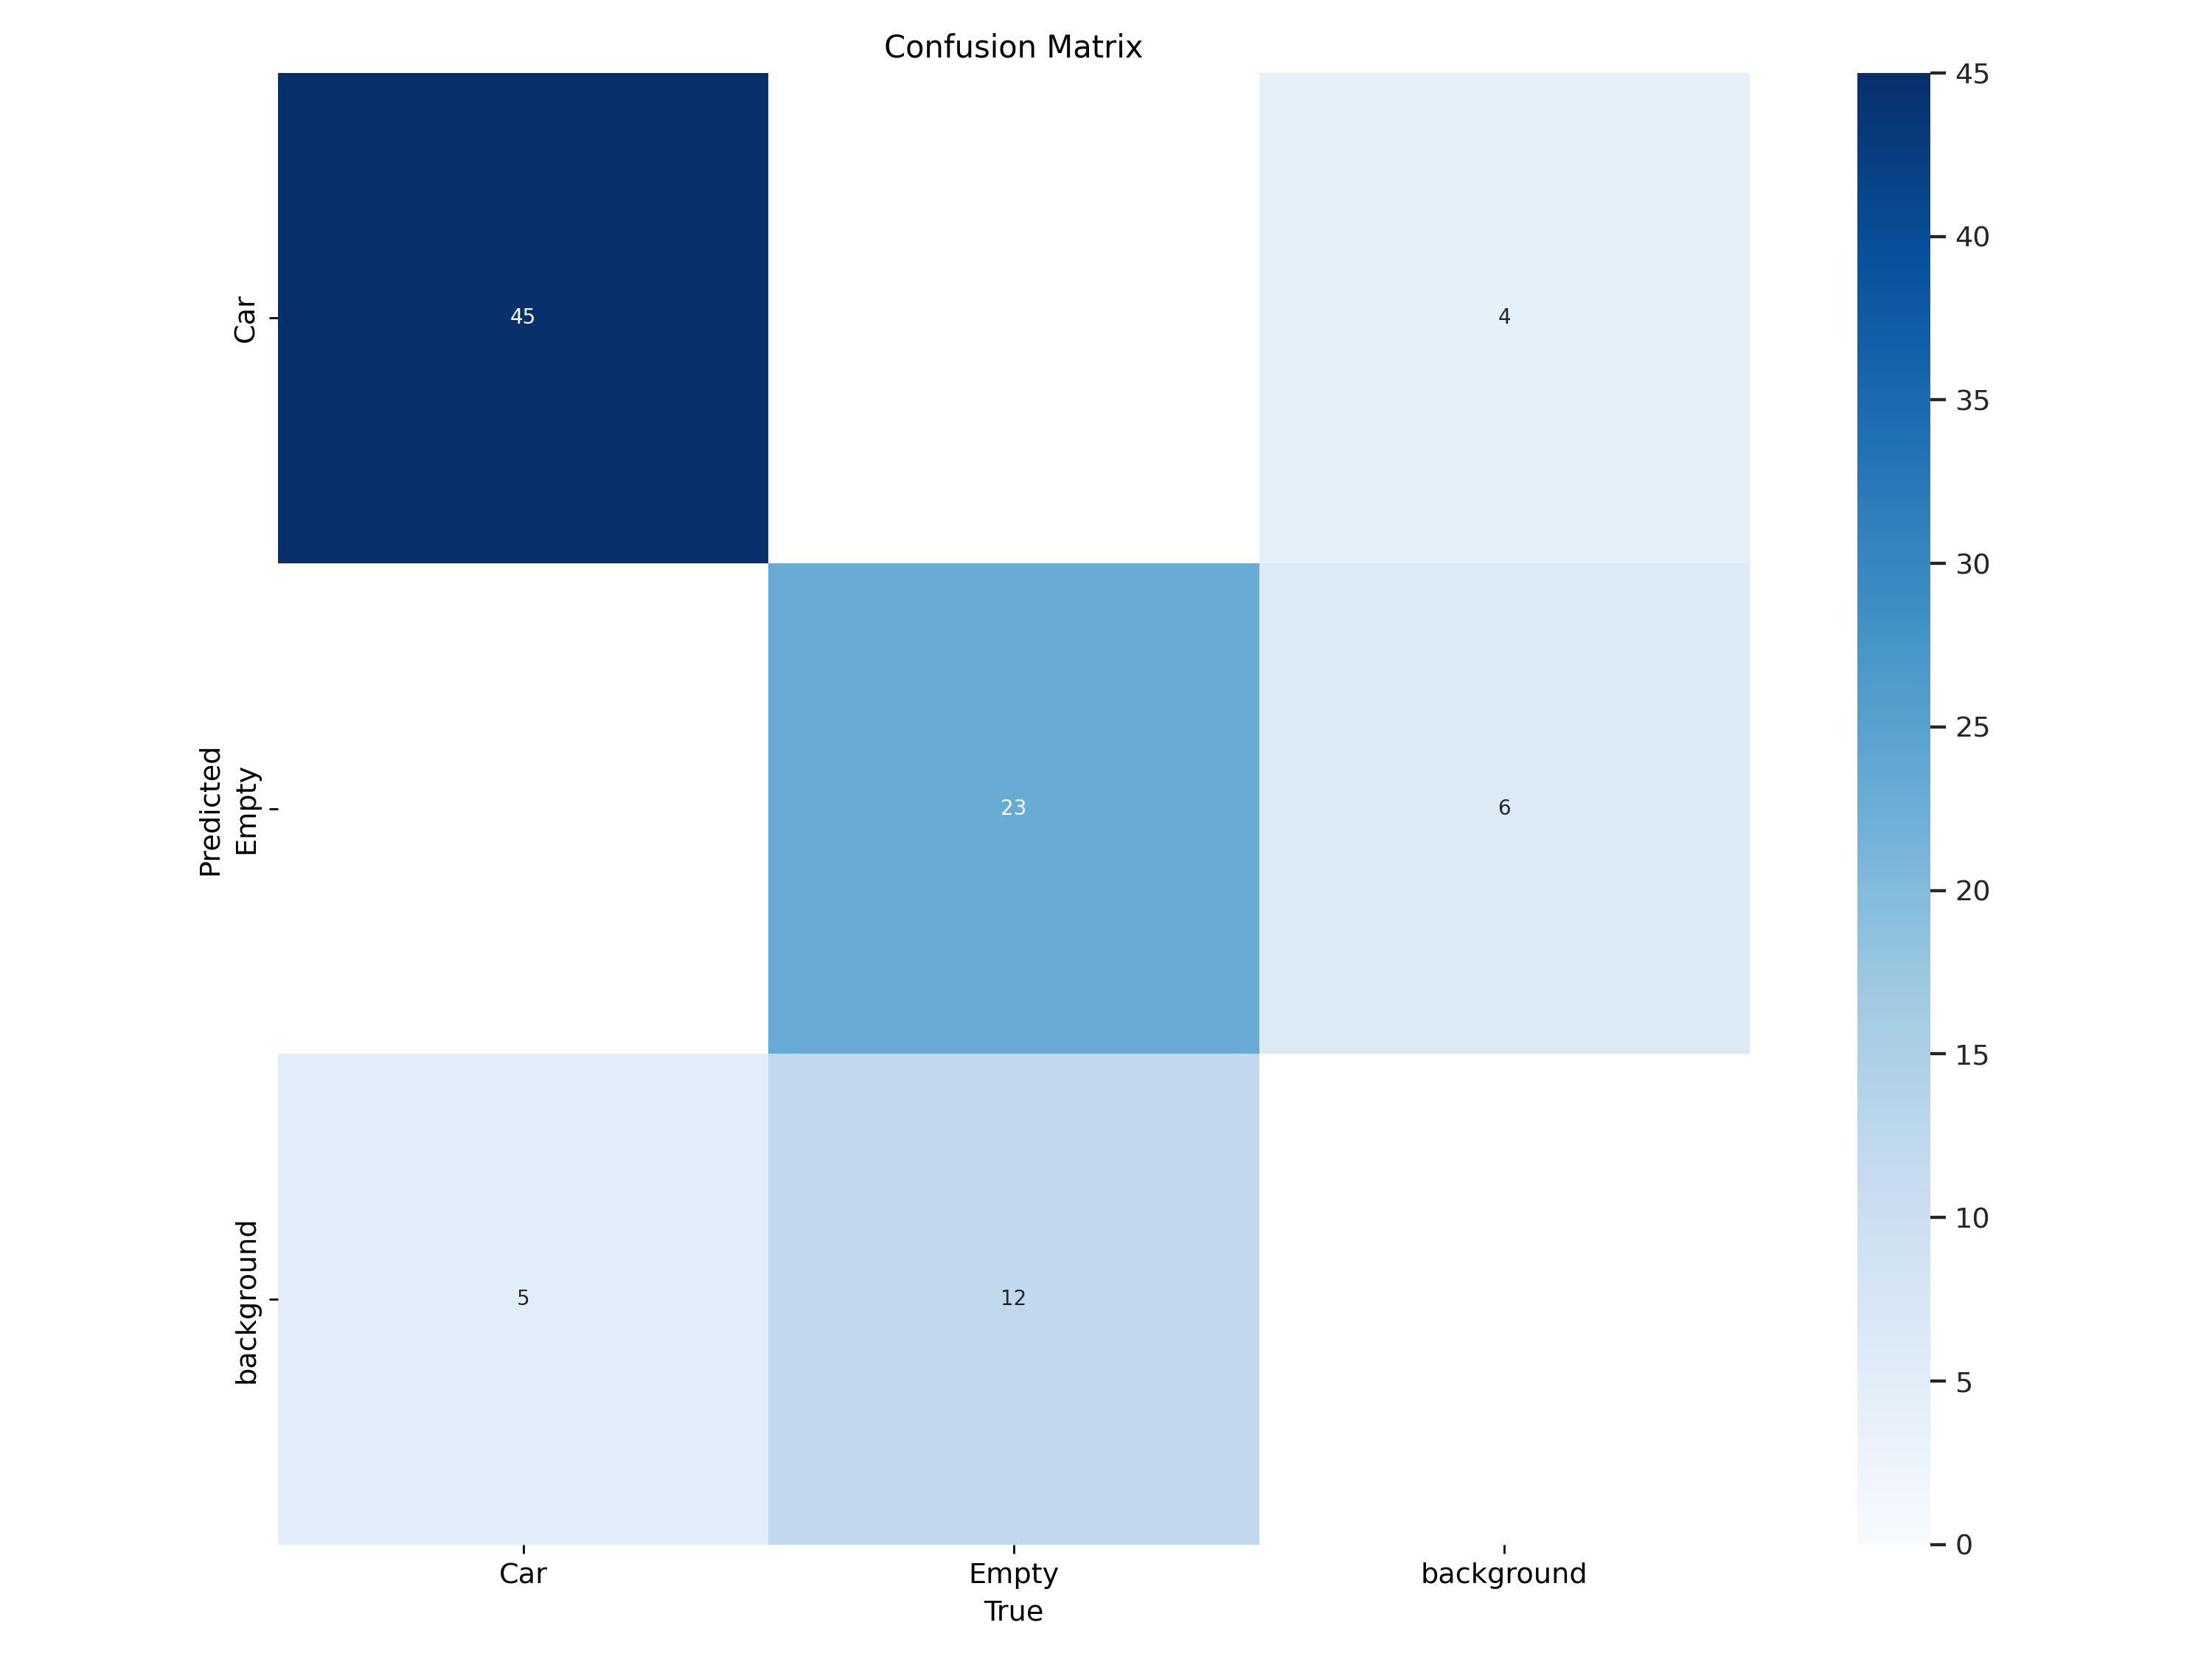

In [ ]:
Image(filename=f'/content/runs/detect/train2/confusion_matrix.png', width=600)

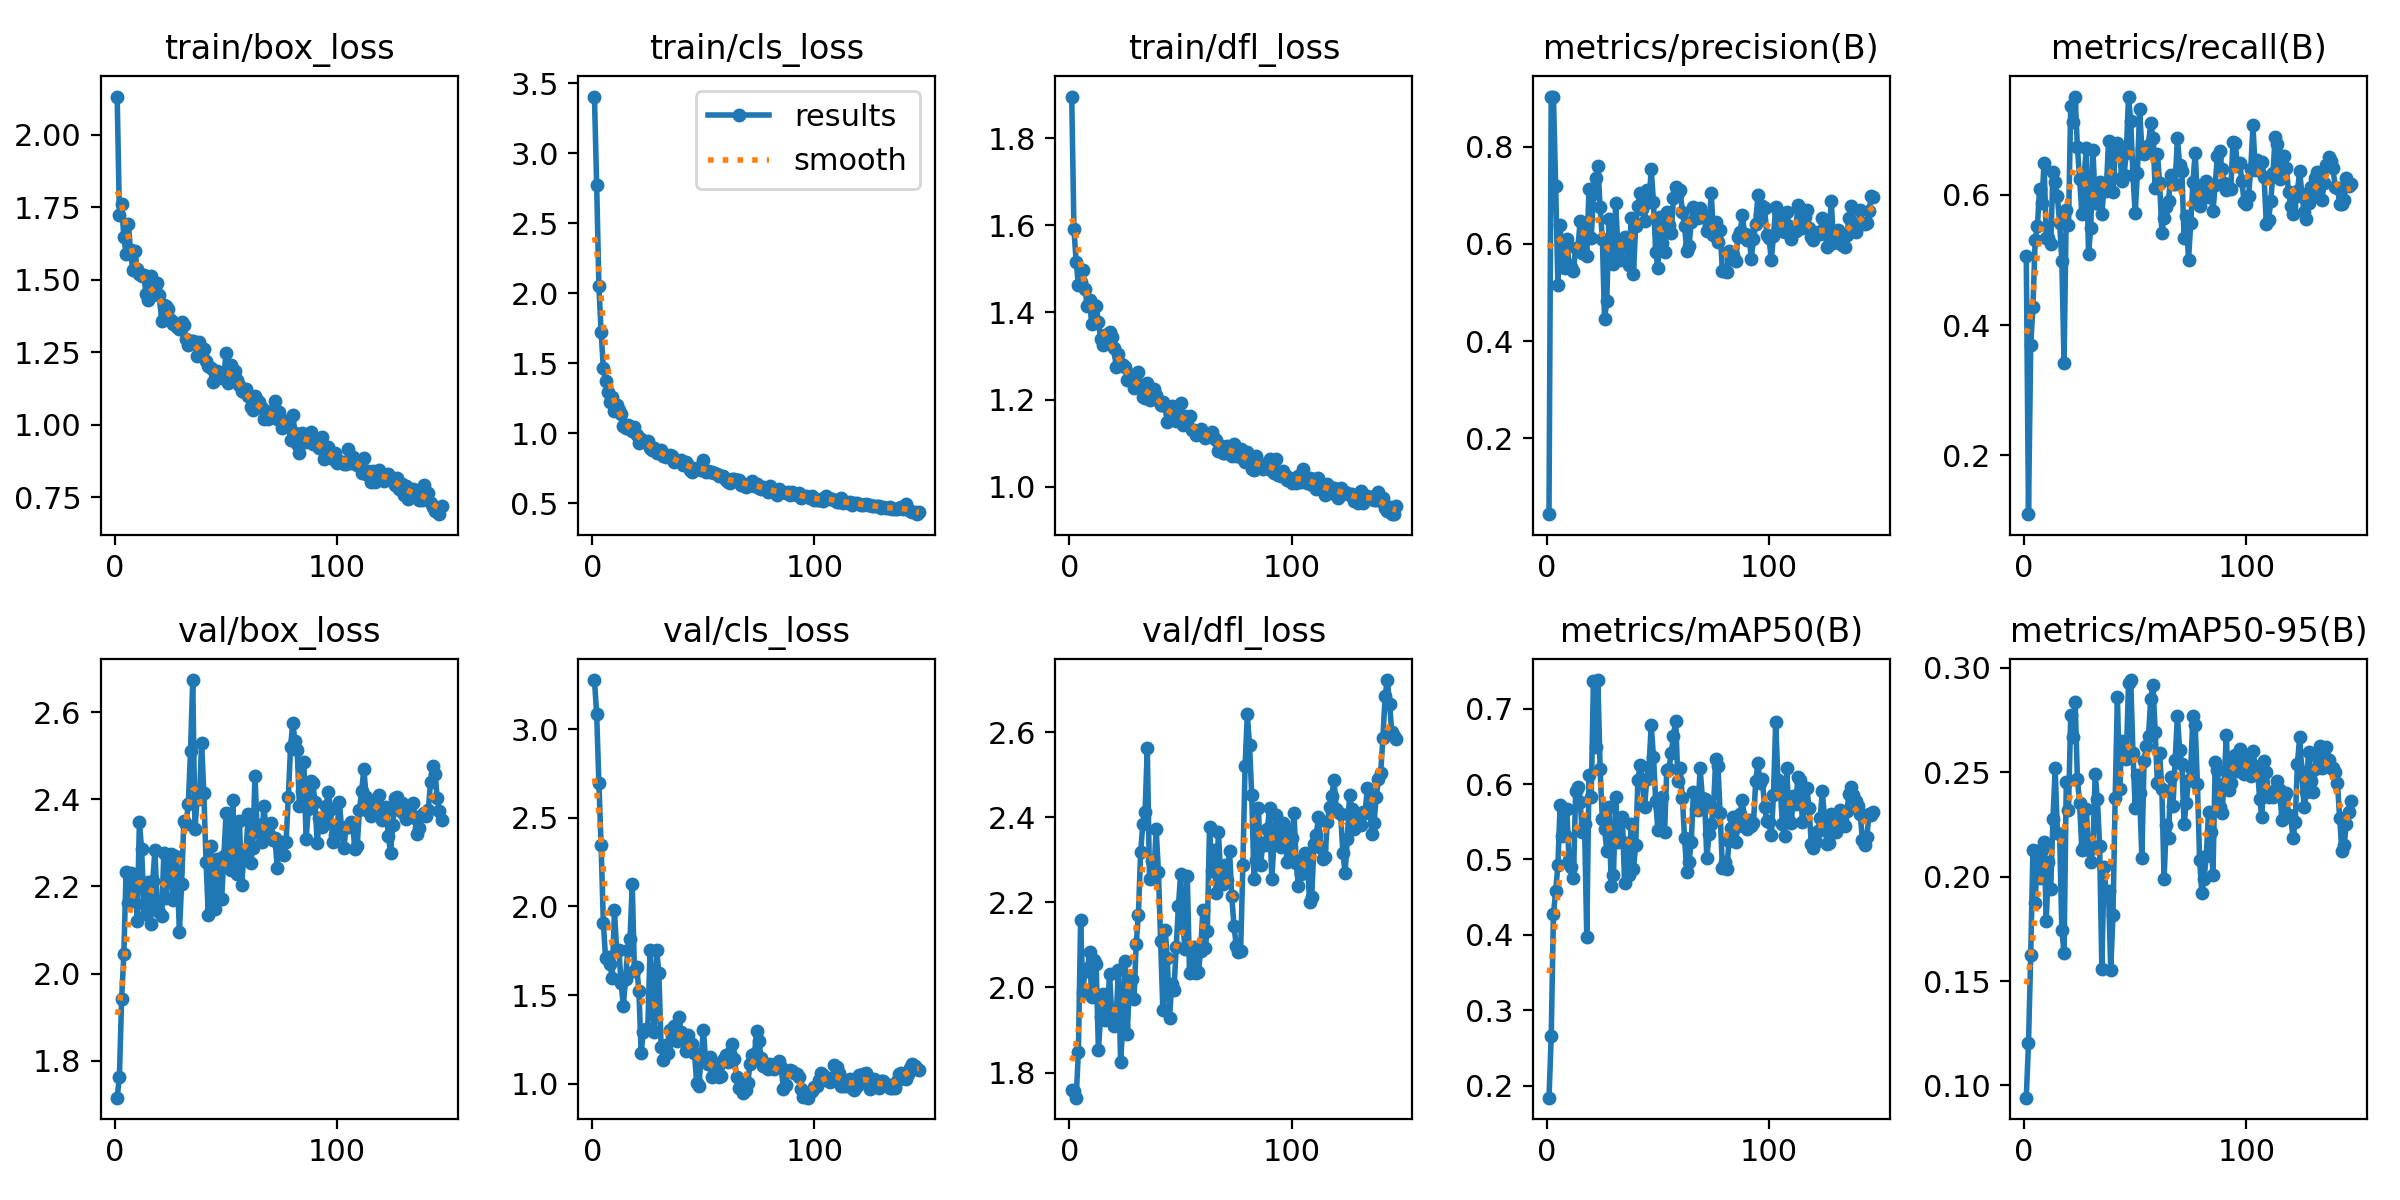

In [ ]:
Image(filename=f'/content/runs/detect/train2/results.png', width=600)

In [ ]:
!yolo task=detect mode=val model=/content/runs/detect/train2/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Scanning /content/datasets/Parking-Lot-Availability-8/valid/labels.cache... 4 images, 0 backgrounds, 0 corrupt: 100% 4/4 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 1/1 [00:00<00:00,  2.94it/s]
                   all          4         85      0.754       0.75      0.679      0.292
                   Car          4         50      0.903      0.933      0.941      0.482
                 Empty          4         35      0.604      0.567      0.417      0.102
Speed: 0.3ms preprocess, 21.5ms inference, 0.0ms loss, 34.8ms postprocess per image
Results saved to runs/detect/val
💡 Learn more at https://docs.ultralytics.com/modes/val


In [ ]:
!yolo task=detect mode=predict model=/content/runs/detect/train2/weights/best.pt conf=0.3 source={dataset.location}/test/images save_txt=true save_conf=true

Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs

image 1/5 /content/datasets/Parking-Lot-Availability-8/test/images/19_png.rf.74ed4838db5303610983dc0fbf4d7589.jpg: 640x640 6 Cars, 5 Emptys, 8.5ms
image 2/5 /content/datasets/Parking-Lot-Availability-8/test/images/33_jpg.rf.b3360302a829f087e9d2cfa37c689a87.jpg: 640x640 14 Cars, 11 Emptys, 7.4ms
image 3/5 /content/datasets/Parking-Lot-Availability-8/test/images/36_jpg.rf.6f567ca39ba8f96d134fa74ad298056c.jpg: 640x640 8 Cars, 9 Emptys, 7.4ms
image 4/5 /content/datasets/Parking-Lot-Availability-8/test/images/3_PNG.rf.116a4cf134e5720ec85c1a9f811bfbd5.jpg: 640x640 7 Cars, 11 Emptys, 7.3ms
image 5/5 /content/datasets/Parking-Lot-Availability-8/test/images/8_PNG.rf.376cf10bf015f8c9cdb497ff79e8d29e.jpg: 640x640 10 Cars, 2 Emptys, 7.3ms
Speed: 3.2ms preprocess, 7.6ms inference, 28.1ms postprocess per image at shape (1, 3, 640, 640)
Res

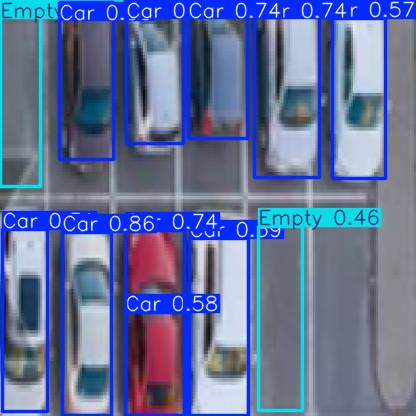

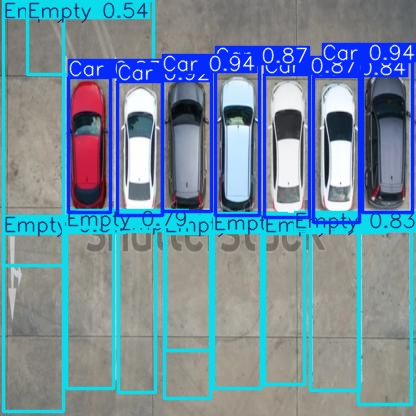

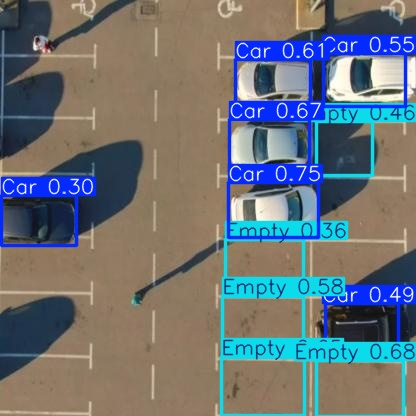

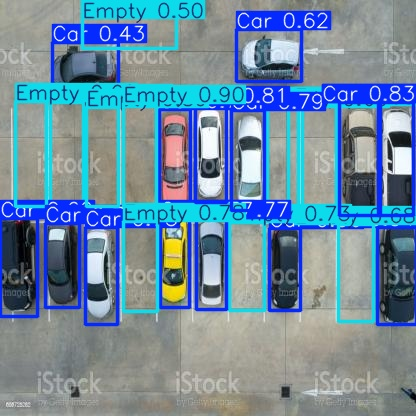

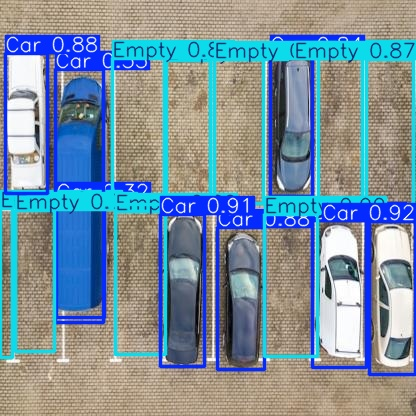

In [ ]:
import glob
from IPython.display import Image, display

for image_path in glob.glob(f'/content/runs/detect/predict/*.jpg'):
      display(Image(filename=image_path, height=600))
      print("\n")